In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from collections import Counter


In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# Convert to DataFrame for easier manipulation
data = pd.DataFrame(data=np.c_[X, y], columns=iris.feature_names + ['target'])

# Split the dataset into training and testing sets (80% training, 20% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
# Function to compute the Euclidean distance
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# KNN algorithm implementation
def knn(X_train, y_train, X_test, k=3):
    predictions = []
    
    for test_point in X_test:
        distances = []
        
        # Calculate the distance between the test point and all training points
        for i, train_point in enumerate(X_train):
            distance = euclidean_distance(test_point, train_point)
            distances.append((distance, y_train[i]))
        
        # Sort by distance and get the labels of the K nearest neighbors
        distances.sort(key=lambda x: x[0])
        k_nearest_neighbors = [label for _, label in distances[:k]]
        
        # Get the most common class (majority voting)
        most_common = Counter(k_nearest_neighbors).most_common(1)
        predictions.append(most_common[0][0])
    
    return predictions


In [4]:
# Test the KNN algorithm with k=3
k = 3
predictions = knn(X_train, y_train, X_test, k)

# Calculate accuracy
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"Accuracy of KNN classifier with k={k}: {accuracy * 100:.2f}%")


Accuracy of KNN classifier with k=3: 100.00%


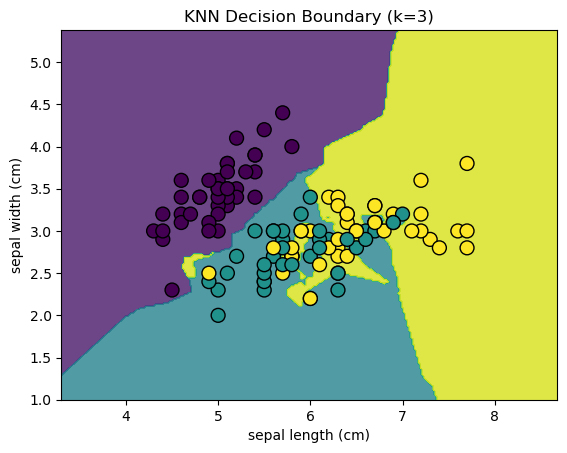

In [6]:
# Plotting decision boundaries for 2D visualization
def plot_decision_boundaries(X_train, y_train, k=3):
    h = .02  # Step size in the mesh
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

    # Create a mesh grid for plotting
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Make predictions for each point in the grid
    Z = knn(X_train, y_train, np.c_[xx.ravel(), yy.ravel()], k)
    Z = np.array(Z).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', marker='o', s=100)
    plt.title(f"KNN Decision Boundary (k={k})")
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.show()

# For 2D plotting, use only two features (for visualization)
X_train_2D = X_train[:, :2]  # Use the first two features for 2D visualization
X_test_2D = X_test[:, :2]    # Use the first two features for 2D visualization

# Plot decision boundaries
plot_decision_boundaries(X_train_2D, y_train, k=k)
